In [13]:
# 01_data_understanding

# ERCOT Electricity Load Forecasting – Data Understanding

This notebook performs exploratory data analysis (EDA) on the ERCOT electricity load dataset as part of the **CRISP-DM Data Understanding stage**.

Objectives:

• Inspect dataset structure and variables  
• Identify missing values and data quality issues  
• Examine statistical properties of electricity demand  
• Visualize load trends and patterns  
• Explore relationships between regional loads and total load

In [14]:
!pip install seaborn 
# Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

In [15]:
# Load Data
path = Path("..") / "data" / "raw" / "ercot_load.csv"
df = pd.read_csv(path)

df.head()

,TIME,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,Load
0,1/1/2024 1:00,"10,484.14","1,375.74","6,210.08","1,250.40","11,799.51","2,929.80","6,020.39","1,153.42","41,223.48"
1,1/1/2024 2:00,"10,365.82","1,455.24","6,223.67","1,272.98","12,094.70","2,916.99","5,987.55","1,162.46","41,479.40"
2,1/1/2024 3:00,"10,206.97","1,396.97","6,270.22","1,290.71","12,414.59","2,835.80","5,874.88","1,182.63","41,472.77"
3,1/1/2024 4:00,"10,086.53","1,424.00","6,263.89","1,311.94","12,609.78","2,783.93","5,789.15","1,208.22","41,477.44"
4,1/1/2024 5:00,"10,097.44","1,507.47","6,281.78","1,335.54","13,158.83","2,741.22","5,816.64","1,245.27","42,184.19"


In [16]:
# Data shape
df.shape

(8784, 10)

In [17]:
# Column Names
df.columns

Index(['TIME', 'COAST', 'EAST', 'FWEST', 'NORTH', 'NCENT', 'SOUTH', 'SCENT',
       'WEST', 'Load'],
      dtype='object')

In [18]:
# Data type
df.dtypes

TIME     object
COAST    object
EAST     object
FWEST    object
NORTH    object
NCENT    object
SOUTH    object
SCENT    object
WEST     object
Load     object
dtype: object

In [19]:
# Missing values
df.isnull().sum()

TIME     0
COAST    0
EAST     0
FWEST    0
NORTH    0
NCENT    0
SOUTH    0
SCENT    0
WEST     0
Load     0
dtype: int64

In [20]:
# Convert Load column to Numeric
for col in df.columns:
    if col != "TIME":
        df[col] = df[col].astype(str).str.replace(",", "")
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [22]:
# Convert Time
df["TIME"] = pd.to_datetime(df["TIME"], errors="coerce", format="mixed")
df.head()

C:\Users\JasHa\AppData\Local\Temp\ipykernel_30084\4048056646.py:2: FutureWarning: Parsed string "11/03/2024 02:00 DST" included an un-recognized timezone "DST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df["TIME"] = pd.to_datetime(df["TIME"], errors="coerce", format="mixed")


,TIME,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,Load
0,2024-01-01 01:00:00,10484.14,1375.74,6210.08,1250.40,11799.51,2929.80,6020.39,1153.42,41223.48
1,2024-01-01 02:00:00,10365.82,1455.24,6223.67,1272.98,12094.70,2916.99,5987.55,1162.46,41479.40
2,2024-01-01 03:00:00,10206.97,1396.97,6270.22,1290.71,12414.59,2835.80,5874.88,1182.63,41472.77
3,2024-01-01 04:00:00,10086.53,1424.00,6263.89,1311.94,12609.78,2783.93,5789.15,1208.22,41477.44
4,2024-01-01 05:00:00,10097.44,1507.47,6281.78,1335.54,13158.83,2741.22,5816.64,1245.27,42184.19


In [23]:
# Summary Statistics
df.describe()

,TIME,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,Load
count,8784,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,2024-07-02 01:09:00.573770496,14013.614751,1731.812760,6576.810385,1481.586284,14737.197025,4174.834051,8473.534252,1348.371341,52537.760911
min,2024-01-01 01:00:00,7128.500000,1032.910000,5232.990000,921.870000,8700.710000,2494.170000,5305.470000,826.880000,35855.650000
25%,2024-04-01 13:45:00,11764.962500,1439.517500,6302.482500,1276.562500,11960.885000,3445.517500,6901.090000,1157.240000,44816.387500
50%,2024-07-02 01:30:00,13297.700000,1621.675000,6558.120000,1426.250000,13635.435000,3999.845000,7905.295000,1266.565000,49580.255000
75%,2024-10-01 13:15:00,15731.097500,1948.325000,6851.175000,1628.697500,16775.497500,4805.852500,9659.107500,1488.530000,58533.250000
max,2025-01-01 00:00:00,23180.170000,3319.350000,7560.050000,2361.950000,27803.180000,6788.350000,15664.700000,2230.500000,85198.850000
std,NaN,2968.129695,413.585487,362.426183,275.100452,3919.357200,909.291914,2089.397612,262.928228,10512.499642


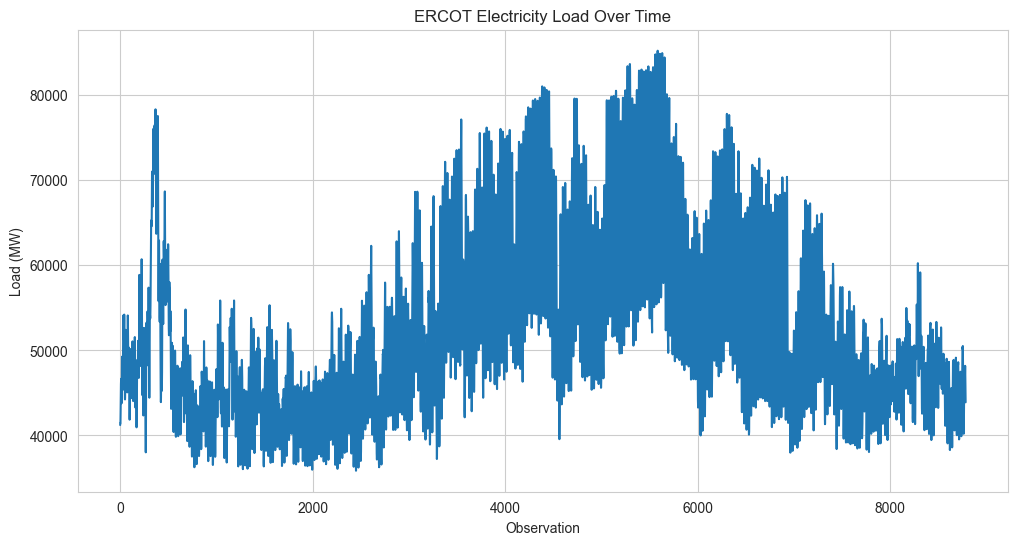

In [24]:
#Visual
plt.figure(figsize=(12,6))
df["Load"].plot()
plt.title("ERCOT Electricity Load Over Time")
plt.xlabel("Observation")
plt.ylabel("Load (MW)")
plt.show()

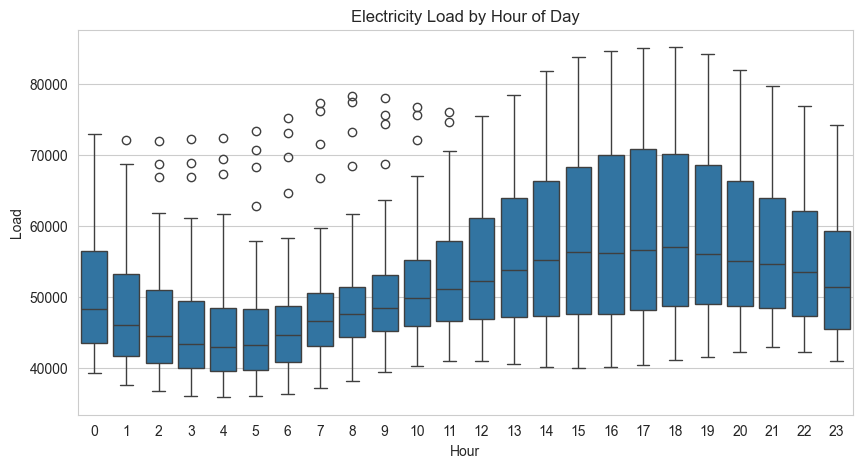

In [25]:
# Hourly Power Demand
df["hour"] = df["TIME"].dt.hour

plt.figure(figsize=(10,5))
sns.boxplot(x="hour", y="Load", data=df)
plt.title("Electricity Load by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Load")
plt.show()

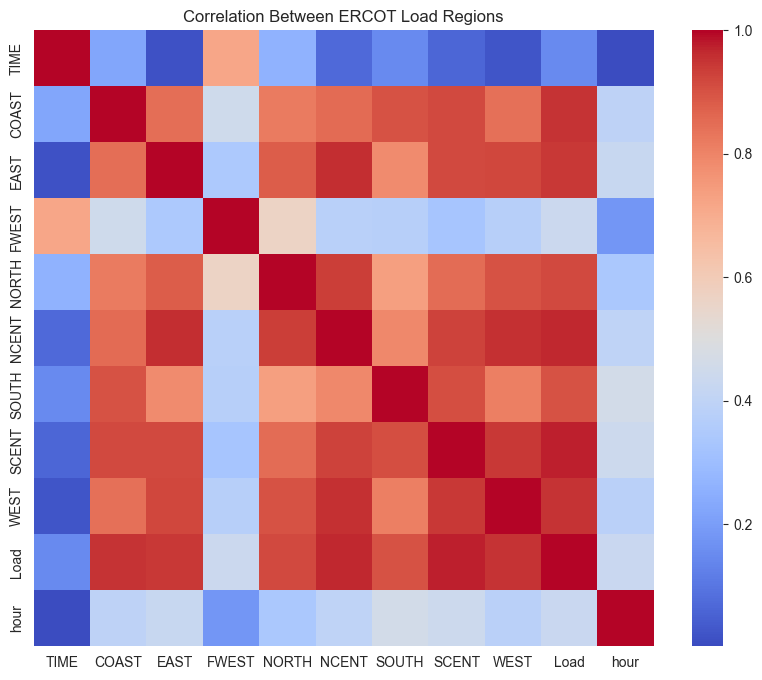

In [26]:
# Regional Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Between ERCOT Load Regions")
plt.show()

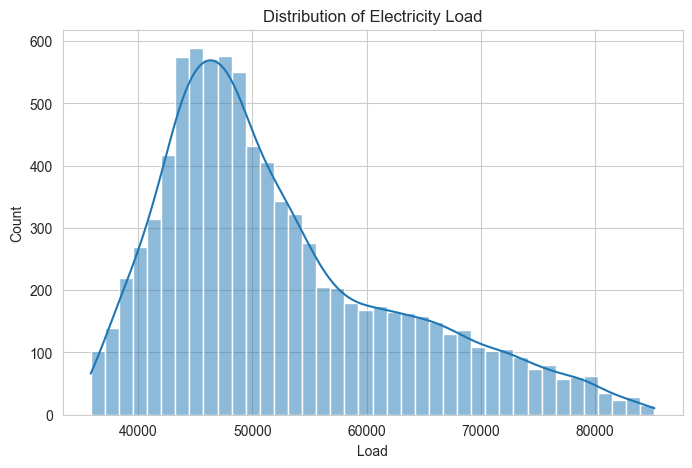

In [27]:
# Distribution of Load
plt.figure(figsize=(8,5))
sns.histplot(df["Load"], bins=40, kde=True)
plt.title("Distribution of Electricity Load")
plt.xlabel("Load")
plt.show()

In [28]:
# save to processed folder
df.to_csv("../data/processed/ercot_eda_preview.csv", index=False)